<a href="https://colab.research.google.com/github/SadiaFerzeen143/decision-tree-classification-/blob/main/decision_tree_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
from google.colab import files

uploaded = files.upload()

Saving spam.csv to spam (1).csv


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [62]:
df = pd.read_csv("spam.csv", encoding="latin-1")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [63]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [64]:
df = df.rename(columns={
    'v1': 'label',
    'v2': 'message'
})

df.head()

,label,message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [65]:
df = df[['label', 'message']]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [66]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5572
Number of columns: 2


In [67]:
df.info()
df.describe(include='all')
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,count
label,
ham,4825
spam,747


In [68]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 403


In [69]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 5169


In [70]:
print("Missing values:")
df.isnull().sum()

Missing values:


,0
label,0
message,0


In [71]:
df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


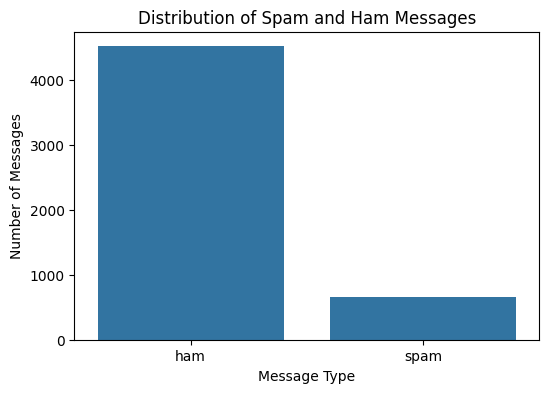

In [72]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='label')

plt.title('Distribution of Spam and Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')

plt.show()

In [73]:
df['message_length'] = df['message'].str.len()

In [74]:
df['word_count'] = df['message'].str.split().str.len()

In [75]:
df['digit_count'] = df['message'].str.count(r'\d')

In [76]:
df[['message', 'message_length', 'word_count', 'digit_count']].head()

,message,message_length,word_count,digit_count
0,"Go until jurong point, crazy.. Available only ...",111,20,0
1,Ok lar... Joking wif u oni...,29,6,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,25
3,U dun say so early hor... U c already then say...,49,11,0
4,"Nah I don't think he goes to usf, he lives aro...",61,13,0


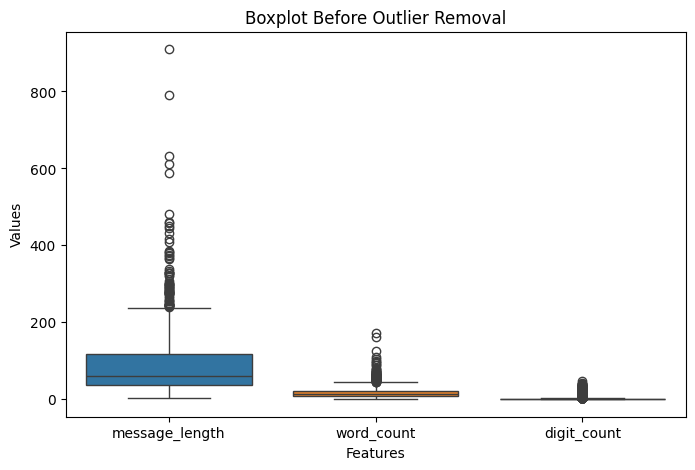

In [77]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df[
    ['message_length', 'word_count', 'digit_count']
])

plt.title('Boxplot Before Outlier Removal')
plt.xlabel('Features')
plt.ylabel('Values')

plt.show()

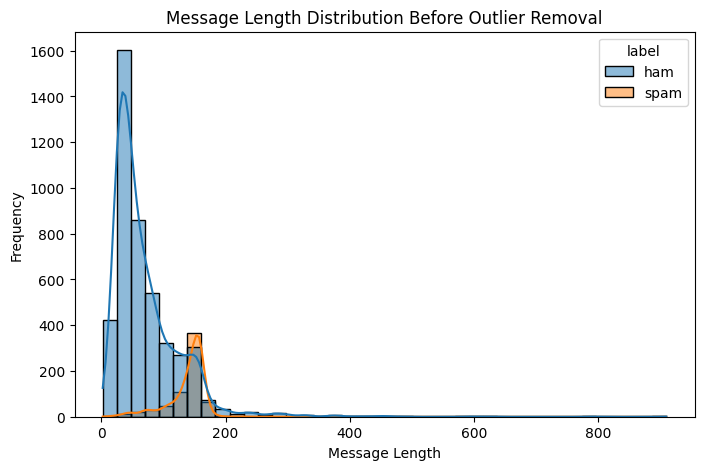

In [78]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='message_length',
    hue='label',
    bins=40,
    kde=True
)

plt.title('Message Length Distribution Before Outlier Removal')
plt.xlabel('Message Length')
plt.ylabel('Frequency')

plt.show()

In [79]:
numeric_features = [
    'message_length',
    'word_count',
    'digit_count'
]

for column in numeric_features:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("Feature:", column)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    print("--------------------------------")

Feature: message_length
Lower Bound: -85.5
Upper Bound: 238.5
Number of Outliers: 66
--------------------------------
Feature: word_count
Lower Bound: -15.5
Upper Bound: 44.5
Number of Outliers: 68
--------------------------------
Feature: digit_count
Lower Bound: -1.5
Upper Bound: 2.5
Number of Outliers: 705
--------------------------------


In [80]:
df_clean = df.copy()

In [81]:
for column in numeric_features:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[column] >= lower_bound) &
        (df_clean[column] <= upper_bound)
    ]

print("Original dataset size:", len(df))
print("Dataset size after outlier removal:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original dataset size: 5169
Dataset size after outlier removal: 4401
Rows removed: 768


In [82]:
df_clean.head()
df_clean.shape

(4401, 6)

In [83]:
df_clean.isnull().sum()

,0
label,0
message,0
label_num,0
message_length,0
word_count,0
digit_count,0


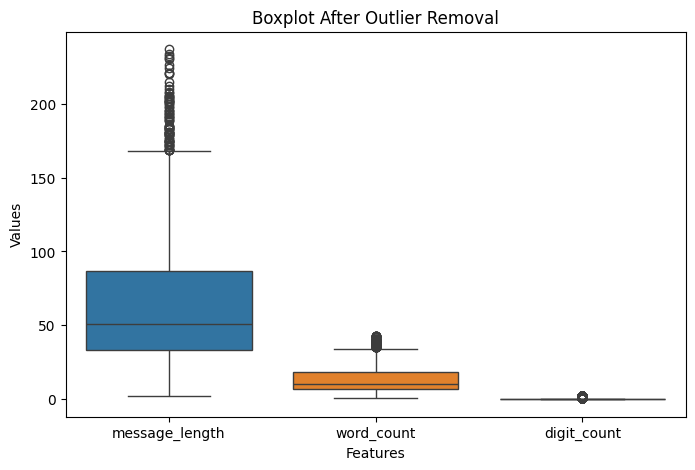

In [84]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_clean[
    ['message_length', 'word_count', 'digit_count']
])

plt.title('Boxplot After Outlier Removal')
plt.xlabel('Features')
plt.ylabel('Values')

plt.show()

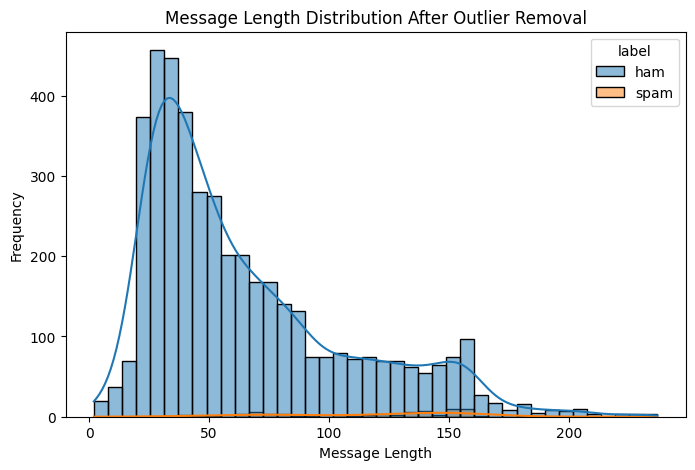

In [85]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x='message_length',
    hue='label',
    bins=40,
    kde=True
)

plt.title('Message Length Distribution After Outlier Removal')
plt.xlabel('Message Length')
plt.ylabel('Frequency')

plt.show()

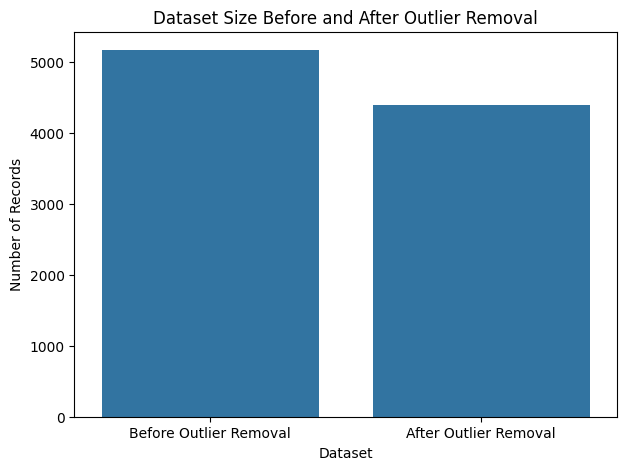

In [86]:
comparison = pd.DataFrame({
    'Dataset': ['Before Outlier Removal', 'After Outlier Removal'],
    'Number of Records': [len(df), len(df_clean)]
})

plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison,
    x='Dataset',
    y='Number of Records'
)

plt.title('Dataset Size Before and After Outlier Removal')
plt.ylabel('Number of Records')

plt.show()

In [87]:
X = df['message']
y = df['label_num']

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [89]:
vectorizer = TfidfVectorizer(
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [90]:
model_before = LogisticRegression(
    max_iter=1000
)

model_before.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [91]:
y_pred_before = model_before.predict(
    X_test_tfidf
)

In [92]:
accuracy_before = accuracy_score(
    y_test,
    y_pred_before
)

print("Accuracy BEFORE Outlier Removal:",
      accuracy_before)

Accuracy BEFORE Outlier Removal: 0.9584139264990329


In [93]:
print("Classification Report BEFORE Outlier Removal:")
print(
    classification_report(
        y_test,
        y_pred_before,
        target_names=['Ham', 'Spam']
    )
)

Classification Report BEFORE Outlier Removal:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.68      0.81       131

    accuracy                           0.96      1034
   macro avg       0.97      0.84      0.89      1034
weighted avg       0.96      0.96      0.96      1034



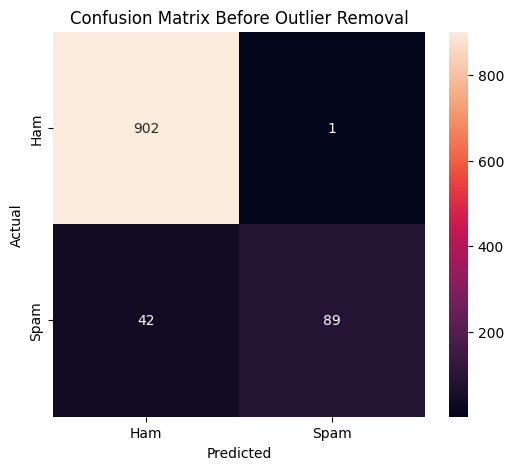

In [94]:
cm_before = confusion_matrix(
    y_test,
    y_pred_before
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_before,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Confusion Matrix Before Outlier Removal')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [95]:
X_after = df_clean['message']
y_after = df_clean['label_num']

In [96]:
X_train_after, X_test_after, y_train_after, y_test_after = train_test_split(
    X_after,
    y_after,
    test_size=0.20,
    random_state=42,
    stratify=y_after
)

print("Training samples after removal:", len(X_train_after))
print("Testing samples after removal:", len(X_test_after))

Training samples after removal: 3520
Testing samples after removal: 881


In [97]:
vectorizer_after = TfidfVectorizer(
    stop_words='english'
)

X_train_after_tfidf = vectorizer_after.fit_transform(
    X_train_after
)

X_test_after_tfidf = vectorizer_after.transform(
    X_test_after
)

In [98]:
model_after = LogisticRegression(
    max_iter=1000
)

model_after.fit(
    X_train_after_tfidf,
    y_train_after
)

LogisticRegression(max_iter=1000)

In [99]:
y_pred_after = model_after.predict(
    X_test_after_tfidf
)

In [100]:
accuracy_after = accuracy_score(
    y_test_after,
    y_pred_after
)

print("Accuracy AFTER Outlier Removal:",
      accuracy_after)

Accuracy AFTER Outlier Removal: 0.9841089670828603


In [101]:
print("Classification Report AFTER Outlier Removal:")

print(
    classification_report(
        y_test_after,
        y_pred_after,
        target_names=['Ham', 'Spam']
    )
)

Classification Report AFTER Outlier Removal:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       867
        Spam       0.00      0.00      0.00        14

    accuracy                           0.98       881
   macro avg       0.49      0.50      0.50       881
weighted avg       0.97      0.98      0.98       881



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


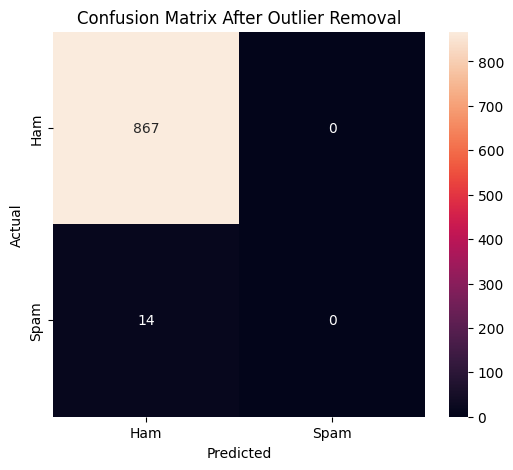

In [102]:
cm_after = confusion_matrix(
    y_test_after,
    y_pred_after
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_after,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Confusion Matrix After Outlier Removal')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [103]:
results = pd.DataFrame({
    'Stage': [
        'Before Outlier Removal',
        'After Outlier Removal'
    ],
    'Accuracy': [
        accuracy_before,
        accuracy_after
    ]
})

print(results)

                    Stage  Accuracy
0  Before Outlier Removal  0.958414
1   After Outlier Removal  0.984109


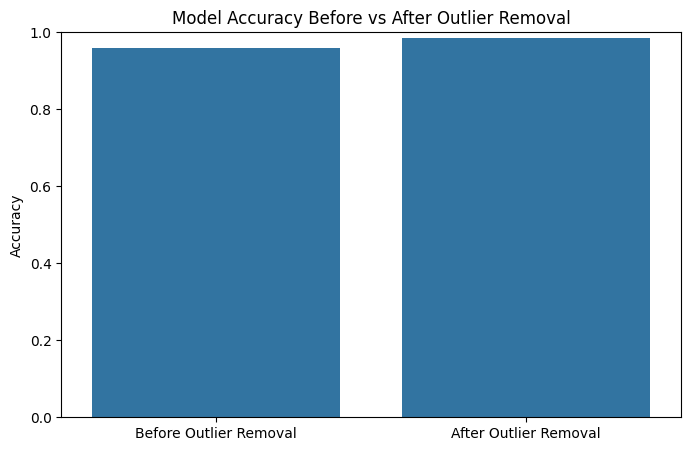

In [104]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Stage',
    y='Accuracy'
)

plt.title('Model Accuracy Before vs After Outlier Removal')
plt.ylabel('Accuracy')
plt.xlabel('')

plt.ylim(0, 1)

plt.show()

Day 2: Machine Learning Model Training and Evaluation

In [105]:
df_clean.head()

,label,message,label_num,message_length,word_count,digit_count
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20,0
1,ham,Ok lar... Joking wif u oni...,0,29,6,0
3,ham,U dun say so early hor... U c already then say...,0,49,11,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13,0
6,ham,Even my brother is not like to speak with me. ...,0,77,16,0


In [106]:
df_clean.columns

Index(['label', 'message', 'label_num', 'message_length', 'word_count',
       'digit_count'],
      dtype='object')

In [107]:
X = df_clean['message']
y = df_clean['label']

In [108]:
y = y.map({'ham': 0, 'spam': 1})

In [109]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [110]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [111]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

In [112]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_tfidf, y_train)

y_pred_dt = dt.predict(X_test_tfidf)

In [113]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

In [114]:
from sklearn.svm import LinearSVC

svm = LinearSVC(random_state=42)

svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

Comparison matrix

In [115]:
from sklearn.metrics import confusion_matrix

print("Logistic Regression:")
print(confusion_matrix(y_test, y_pred_lr))

print("Decision Tree:")
print(confusion_matrix(y_test, y_pred_dt))

print("Naive Bayes:")
print(confusion_matrix(y_test, y_pred_nb))

print("SVM:")
print(confusion_matrix(y_test, y_pred_svm))

Logistic Regression:
[[867   0]
 [ 14   0]]
Decision Tree:
[[865   2]
 [ 10   4]]
Naive Bayes:
[[867   0]
 [ 14   0]]
SVM:
[[867   0]
 [ 10   4]]


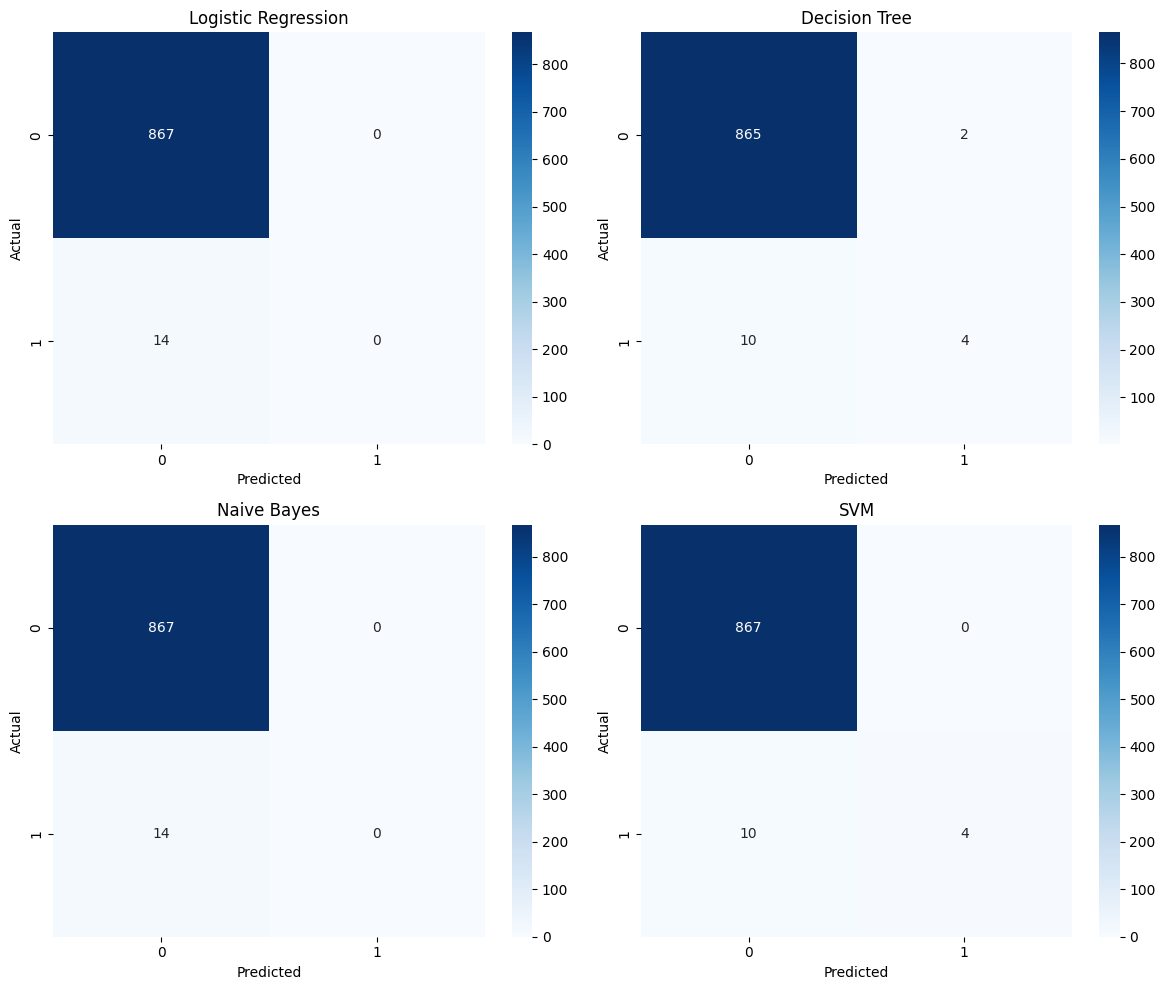

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Logistic Regression')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('Decision Tree')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Naive Bayes')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('SVM')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [119]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for Logistic Regression
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)

# Calculate metrics for Decision Tree
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, zero_division=0)
rec_dt = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, zero_division=0)

# Calculate metrics for Naive Bayes
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, zero_division=0)
rec_nb = recall_score(y_test, y_pred_nb, zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, zero_division=0)

# Calculate metrics for SVM
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, zero_division=0)
rec_svm = recall_score(y_test, y_pred_svm, zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, zero_division=0)

# Create a new DataFrame for model evaluation comparison
evaluation_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Naive Bayes', 'SVM'],
    'Accuracy': [acc_lr, acc_dt, acc_nb, acc_svm],
    'Precision': [prec_lr, prec_dt, prec_nb, prec_svm],
    'Recall': [rec_lr, rec_dt, rec_nb, rec_svm],
    'F1 Score': [f1_lr, f1_dt, f1_nb, f1_svm]
})

print(evaluation_df)


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.984109   0.000000  0.000000  0.000000
1        Decision Tree  0.986379   0.666667  0.285714  0.400000
2          Naive Bayes  0.984109   0.000000  0.000000  0.000000
3                  SVM  0.988649   1.000000  0.285714  0.444444


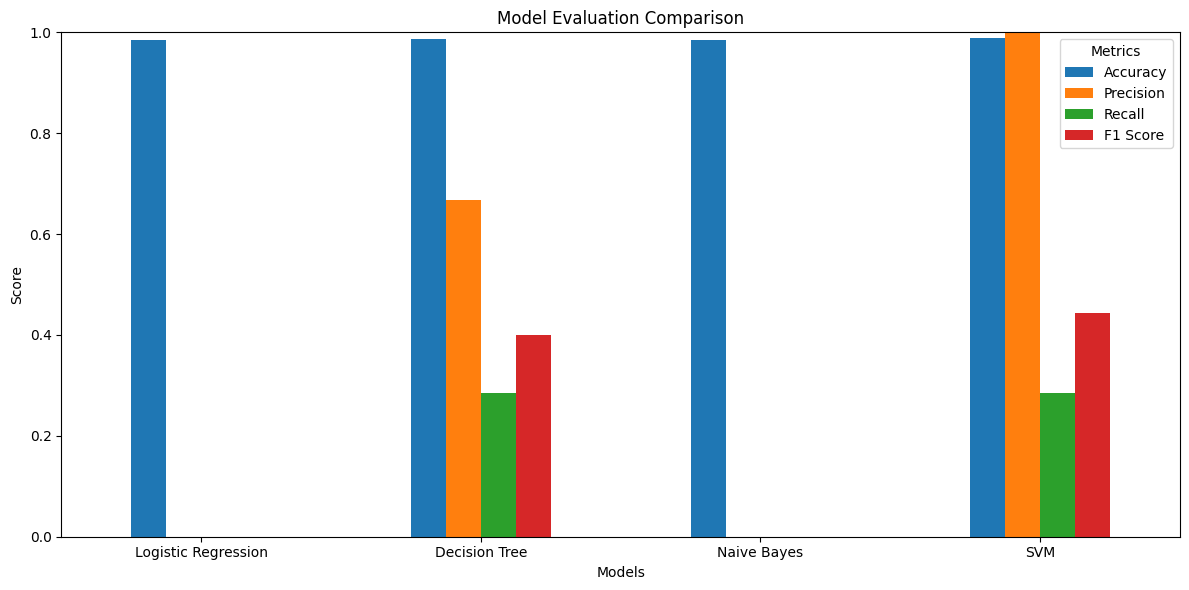

In [120]:
import matplotlib.pyplot as plt

evaluation_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Model Evaluation Comparison')
plt.xlabel('Models')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

In [121]:
df_clean.head()

,label,message,label_num,message_length,word_count,digit_count
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20,0
1,ham,Ok lar... Joking wif u oni...,0,29,6,0
3,ham,U dun say so early hor... U c already then say...,0,49,11,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13,0
6,ham,Even my brother is not like to speak with me. ...,0,77,16,0


In [122]:
print(df_clean.columns)

Index(['label', 'message', 'label_num', 'message_length', 'word_count',
       'digit_count'],
      dtype='object')


In [123]:
X_text = df_clean["message"]
y = df_clean["label"]

In [129]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['ham' 'spam']


In [130]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000
)

X_tfidf = tfidf.fit_transform(X_text)

In [131]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [132]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

In [133]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [134]:
from sklearn.metrics import accuracy_score

y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.9863791146424518


In [135]:
tree = dt_model.tree_

feature_names = tfidf.get_feature_names_out()

In [136]:
feature_index = tree.feature[0]
threshold = tree.threshold[0]

feature = feature_names[feature_index]

print("Split 1")
print("----------------")
print("Feature:", feature)
print("Threshold:", threshold)
print("Gini:", tree.impurity[0])
print("Samples:", tree.n_node_samples[0])

Split 1
----------------
Feature: www
Threshold: 0.09967377781867981
Gini: 0.03186192536157029
Samples: 3520


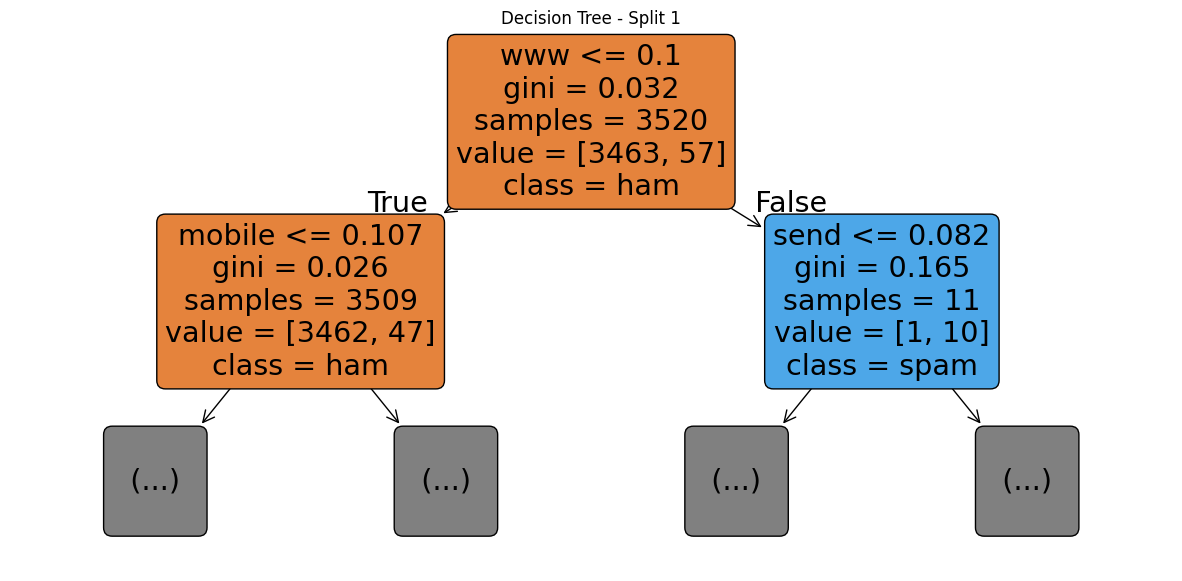

In [137]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 7))

plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    max_depth=1
)

plt.title("Decision Tree - Split 1")

plt.show()

In [138]:
left_child = tree.children_left[0]
right_child = tree.children_right[0]

print("Split 2")
print("----------------")

if tree.feature[left_child] != -2:
    print(
        "Left Branch:",
        feature_names[tree.feature[left_child]],
        "<=",
        tree.threshold[left_child]
    )

if tree.feature[right_child] != -2:
    print(
        "Right Branch:",
        feature_names[tree.feature[right_child]],
        "<=",
        tree.threshold[right_child]
    )

Split 2
----------------
Left Branch: mobile <= 0.10691027343273163
Right Branch: send <= 0.08243478089570999


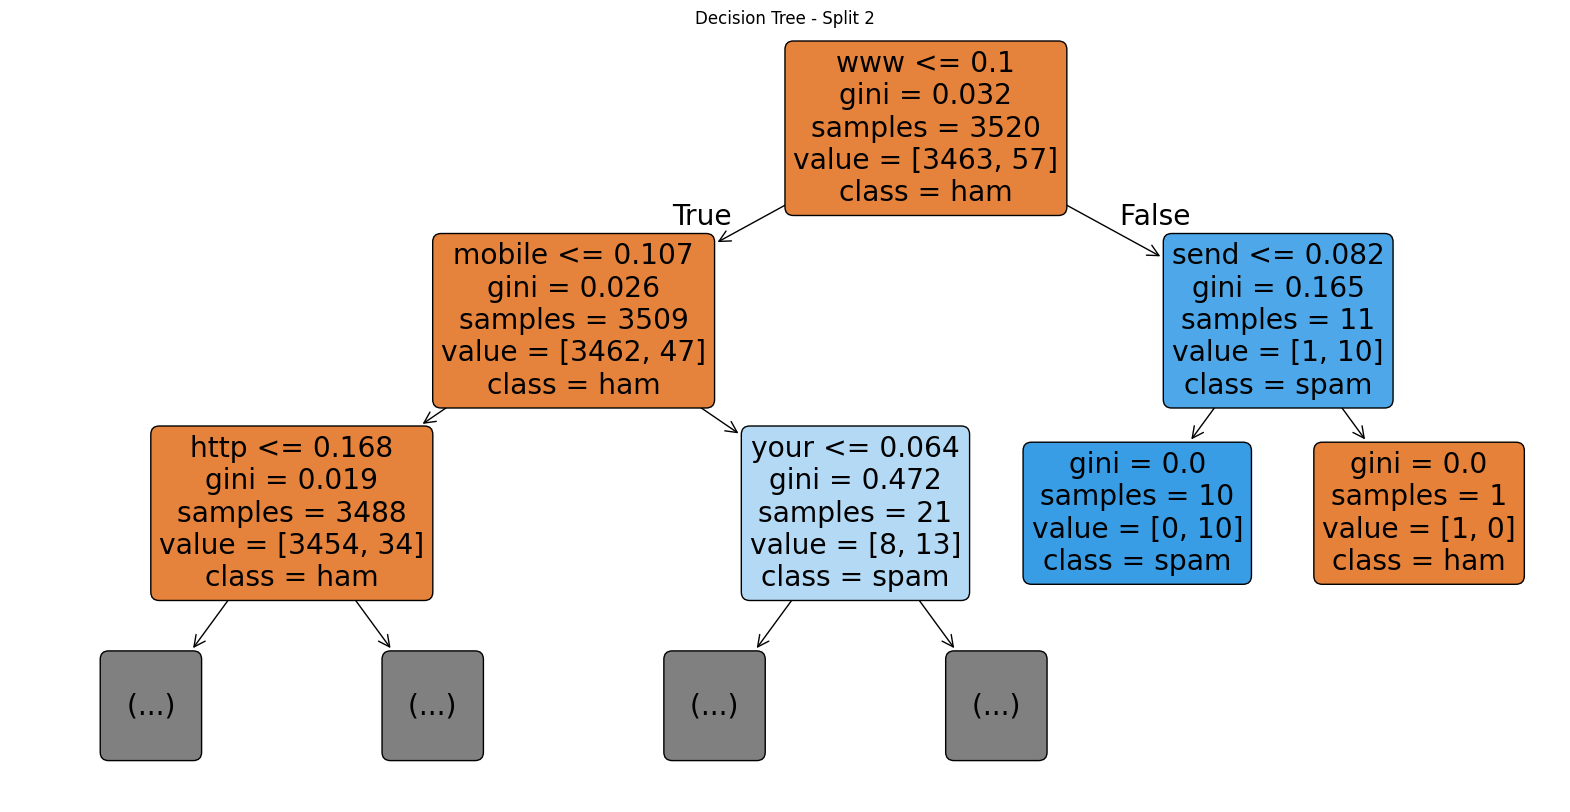

In [139]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    max_depth=2
)

plt.title("Decision Tree - Split 2")

plt.show()

In [141]:
for node in range(tree.node_count):

    if tree.feature[node] != -2:
        print(
            "Node", node,
            ":",
            feature_names[tree.feature[node]],
            "<=",
            tree.threshold[node]
        )

Node 0 : www <= 0.09967377781867981
Node 1 : mobile <= 0.10691027343273163
Node 2 : http <= 0.1677314192056656
Node 5 : your <= 0.06425131857395172
Node 8 : send <= 0.08243478089570999


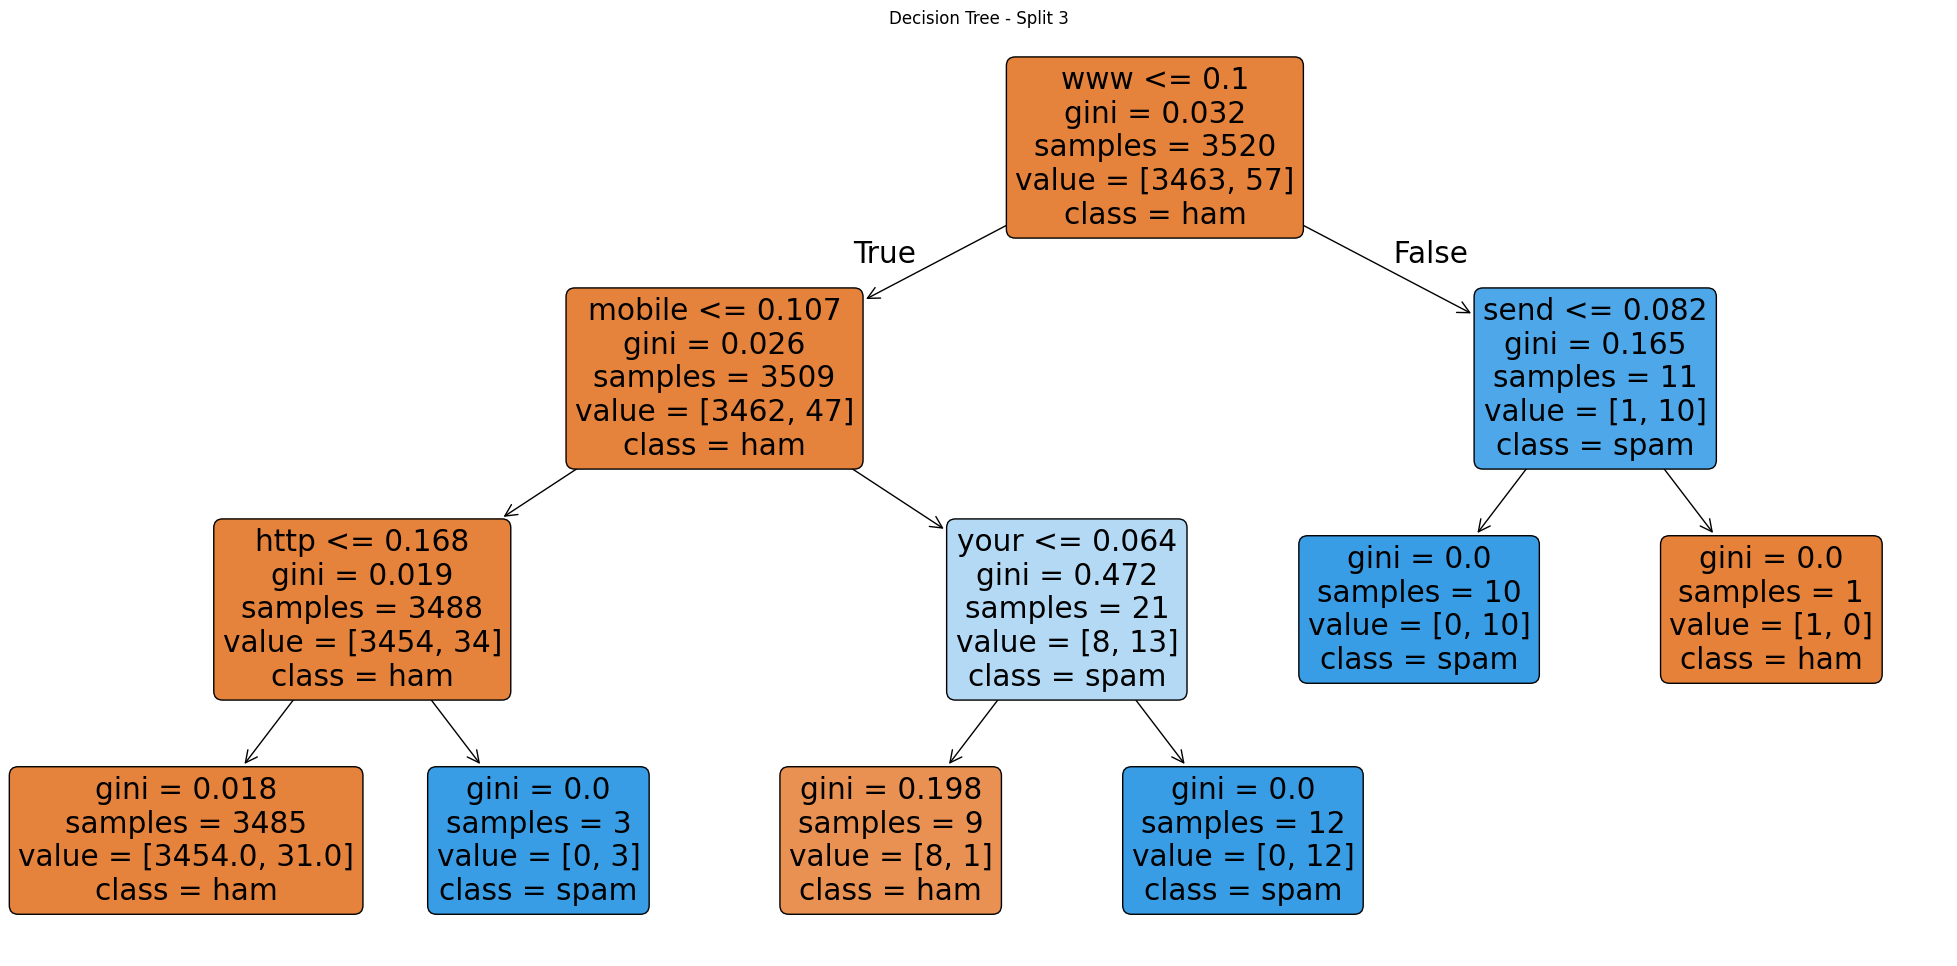

In [142]:
plt.figure(figsize=(25, 12))

plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree - Split 3")

plt.show()

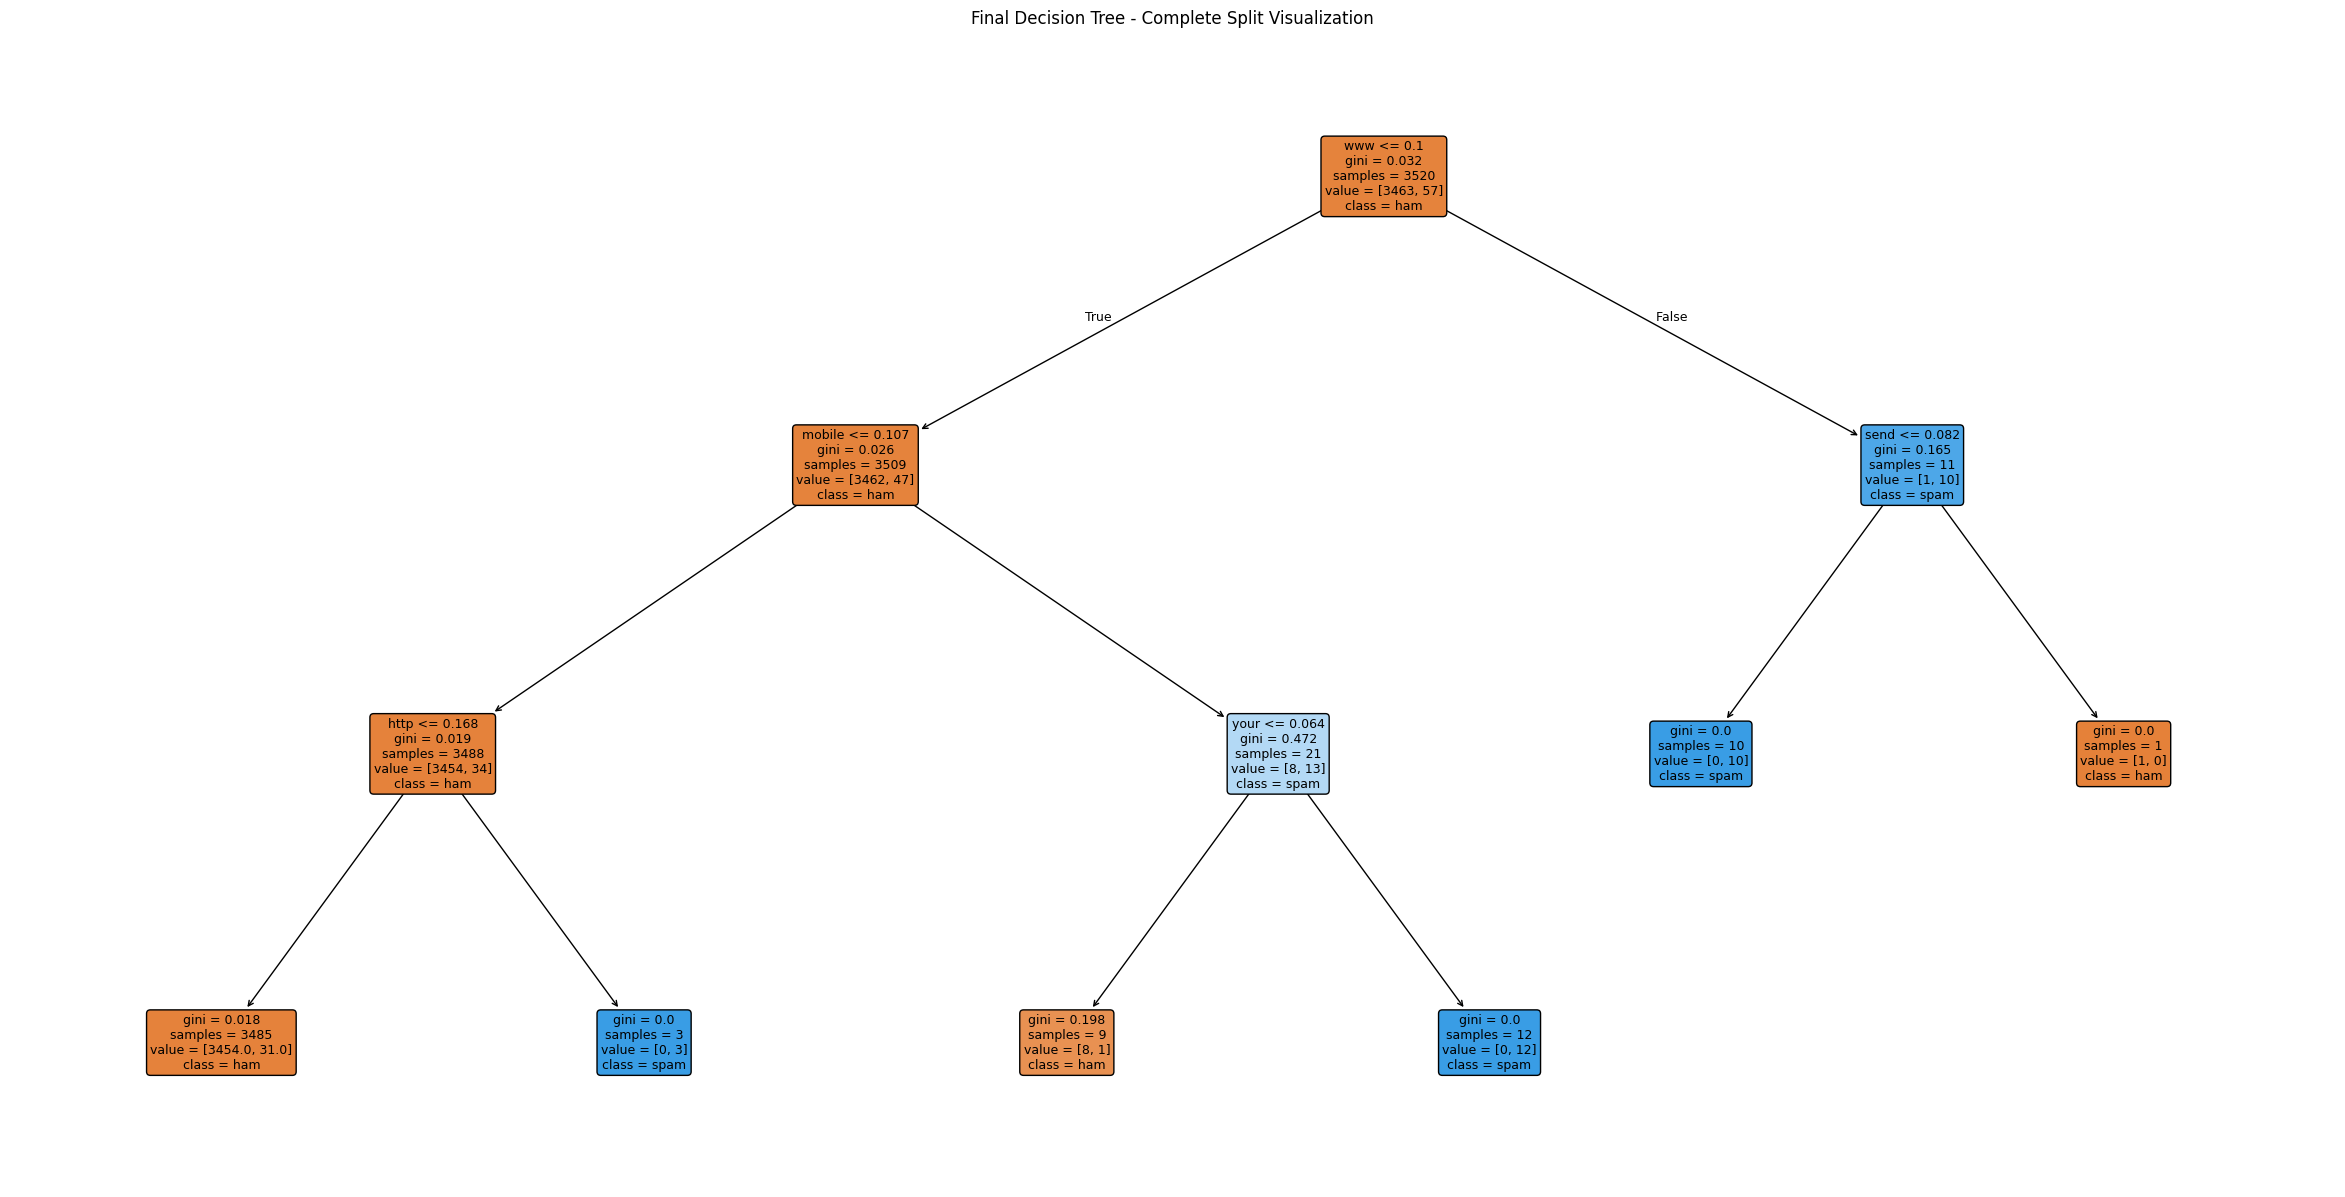

In [143]:
plt.figure(figsize=(30, 15))

plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Final Decision Tree - Complete Split Visualization")

plt.show()